## Modelo base (baseline): heurística clínica

### Proyecto:
Pacientes con problemas de hígado - India

**Autor:** Mariana Bedoya Arismendy

### Fecha:
2026-08-19

### Incidencia:
11 - Modelo base (baseline)

### Descripción:

Este notebook construye el **modelo base (baseline)** del proyecto: la referencia
sencilla, interpretable y reproducible contra la cual se compararán los modelos de
Machine Learning de la siguiente etapa. El baseline seleccionado es una heurística
clínica: un paciente se clasifica como "posibles problemas de hígado" si **al menos
una** de cuatro pruebas hepáticas (bilirrubina total, ALT, AST o albúmina) está
fuera de su rango de referencia de laboratorio.

Antes de implementarla se analizan las alternativas (clasificador dummy de clase
mayoritaria, dummy por previa de clases y la heurística clínica) y la selección se
decide con validación cruzada únicamente sobre el conjunto de entrenamiento.

El flujo del notebook:

1. **Definición del problema**: variable objetivo, distribución de clases, errores
   relevantes y riesgos de fuga de información.
2. **Preparación de los datos**: la misma limpieza y división entrenamiento/prueba
   de la etapa de Feature Engineering.
3. **Selección del modelo base**: alternativas, comparación y justificación.
4. **Evaluación**: métricas, matriz de confusión y curvas ROC/precision-recall
   sobre el conjunto de prueba.
5. **Diagnóstico**: validación cruzada, curva de aprendizaje y escalabilidad.
6. **Conclusiones, recomendaciones y propuestas** para la etapa de modelado.

## 📚 Importar librerías

Importamos `pandas` y `numpy` para manipular los datos, los componentes de
scikit-learn para construir el pipeline y evaluar modelos (`Pipeline`,
`ColumnTransformer`, imputadores, `DummyClassifier`, validación cruzada, curva de
aprendizaje y métricas), y `matplotlib` para las gráficas. `BaseEstimator` y
`ClassifierMixin` permiten definir la heurística como un estimador compatible con
toda la interfaz de scikit-learn.

In [20]:
# librerías base para ciencia de datos
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn as sk
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay,
    RocCurveDisplay,
    average_precision_score,
    classification_report,
    roc_auc_score,
)
from sklearn.model_selection import (
    ShuffleSplit,
    StratifiedKFold,
    cross_val_score,
    learning_curve,
    train_test_split,
)
from sklearn.pipeline import Pipeline

## 💾 Cargar datos

Cargamos el mismo archivo Parquet de la etapa intermedia que usaron la exploración,
el EDA y el Feature Engineering: las 11 variables clínicas con los tipos de datos
ya corregidos. La ruta se construye de forma relativa a la raíz del proyecto para
que el notebook funcione en cualquier instalación.

In [ ]:
DATA_DIR = Path.cwd().resolve().parents[1] / "data"
DATA_PATH = (
    DATA_DIR / "02_intermediate/Pacientes_porblemas_higado_india_type_fixed.parquet"
)

assert DATA_PATH.exists(), f"No se encuentra el archivo del proyecto: {DATA_PATH}"

pacientes_df = pd.read_parquet(DATA_PATH, engine="pyarrow")

print(
    f"Dataset cargado: {pacientes_df.shape[0]} filas y {pacientes_df.shape[1]} columnas"
)
pacientes_df.head()

Dataset cargado: 663 filas y 11 columnas


,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Protiens,Albumin,Albumin_and_Globulin_Ratio,Dataset
0,65,Female,0.7,0.1,187.0,16.0,18.0,6.8,3.3,0.9,1
1,62,Male,10.9,5.5,699.0,64.0,100.0,7.5,3.2,0.74,1
2,62,Male,7.3,4.1,490.0,60.0,68.0,7.0,3.3,0.89,1
3,58,Male,1.0,0.4,182.0,14.0,20.0,6.8,3.4,1.0,1
4,72,Male,3.9,2.0,195.0,27.0,59.0,7.3,2.4,0.4,1


In [22]:
# versiones de las librerías para reproducibilidad
print("Versión de Python:", sys.version)
print("Versión de pandas:", pd.__version__)
print("Versión de numpy:", np.__version__)
print("Versión de scikit-learn:", sk.__version__)

Versión de Python: 3.12.11 (main, Jul  1 2025, 05:29:09) [GCC 12.2.0]
Versión de pandas: 3.0.5
Versión de numpy: 2.5.2
Versión de scikit-learn: 1.9.0


## 🎯 Definición del problema

El problema es de **clasificación binaria**: predecir si un paciente tiene problemas
de hígado a partir de un panel de pruebas de función hepática.

- **Variable objetivo**: `Dataset`, con etiquetas `'1'` (problemas de hígado, clase
  positiva) y `'2'` (sin problemas). Igual que en la etapa de Feature Engineering,
  la recodificamos como 1/0 para los clasificadores de scikit-learn.
- **Variables predictoras**: las 10 restantes (edad, género y las ocho pruebas
  hepáticas). Todas están disponibles en el momento de la predicción: son
  resultados de laboratorio del propio panel diagnóstico, ninguna se mide después
  del diagnóstico ni se deriva del objetivo. No hay identificadores, fechas ni
  variables posteriores al evento, así que el dataset no contiene fuentes
  estructurales de data leakage; lo que se predice es precisamente el juicio
  clínico que un especialista haría con este panel.

El EDA documentó dos rasgos que condicionan esta etapa:

1. **Desbalance moderado de clases**: entre los pacientes con etiqueta hay 460 con
   problemas de hígado y 188 sin ellos (~71% / 29%). Un clasificador tonto que
   siempre diga "enfermo" acierta cerca del 71% de las veces, así que la accuracy
   por sí sola puede resultar engañosa.
2. **Dataset pequeño**: 663 registros, que tras la limpieza quedan en 585. Con tan
   pocos datos la variabilidad de las métricas importa, y por eso se reportan
   medias y desviaciones estándar de la validación cruzada.

### ¿Qué errores son relevantes?

En un contexto de tamizaje clínico, el error más costoso es el **falso negativo**:
un paciente enfermo al que se le dice que no tiene problemas. Por eso la métrica
prioritaria es el *recall* de la clase 1. Los **falsos positivos** (sanos marcados
como enfermos) tienen un costo menor pero real: seguimientos innecesarios y
sobrecarga del sistema, así que también se vigila la especificidad.

In [23]:
print(
    "Distribución de la variable objetivo Dataset ('1': problemas de hígado, '2': sin problemas):"
)
print(pacientes_df["Dataset"].value_counts(dropna=False))

Distribución de la variable objetivo Dataset ('1': problemas de hígado, '2': sin problemas):
Dataset
1      460
2      188
NaN     15
Name: count, dtype: int64


De los 663 registros, 460 tienen etiqueta `'1'`, 188 etiqueta `'2'` y 15 no tienen
etiqueta. La clase positiva representa el 70,9% de los pacientes etiquetados: es
el desbalance documentado en el EDA. Los 15 registros sin etiqueta se descartan en
la limpieza, porque la variable objetivo no se imputa.

## 🧹 Limpieza previa a la separación de los datos

Aplicamos exactamente la misma limpieza de la etapa de Feature Engineering, con las
mismas decisiones y el mismo orden, para que esta etapa parta de los mismos 585
registros:

1. **Duplicados exactos** (60 filas): se eliminan antes del split porque un
   registro idéntico en entrenamiento y prueba es una vía directa de fuga de
   información.
2. **Filas sin etiqueta** (15): sin valor en `Dataset` no sirven para aprendizaje
   supervisado; la variable objetivo no se imputa.
3. **Bilirrubinas inconsistentes** (3 filas con bilirrubina directa mayor que la
   total): errores de captura fisiológicamente imposibles y sin fuente para
   corregirlos.

Los valores extremos de las pruebas hepáticas no se eliminan: el EDA concluyó que
son clínicamente posibles en pacientes graves, y son justamente los pacientes que
interesa detectar. La heurística de esta etapa los compara contra umbrales clínicos
en sus unidades originales, así que no necesita ninguna transformación de escala.

In [ ]:
# 1. Duplicados exactos: se eliminan antes del split para que registros idénticos
#    no terminen simultáneamente en entrenamiento y prueba.
filas_iniciales = len(pacientes_df)
limpio_df = pacientes_df.drop_duplicates()
print(
    f"Tras eliminar duplicados: {len(limpio_df)} filas (-{filas_iniciales - len(limpio_df)})"
)

# 2. Registros sin etiqueta en el objetivo: no sirven para el entrenamiento supervisado.
filas_sin_etiqueta = int(limpio_df["Dataset"].isna().sum())
limpio_df = limpio_df[limpio_df["Dataset"].notna()]
print(
    f"Tras descartar filas sin etiqueta: {len(limpio_df)} filas (-{filas_sin_etiqueta})"
)

# 3. Filas con bilirrubina directa mayor que la total: errores de captura
#    fisiológicamente imposibles y sin fuente para corregirlos.
#    Las comparaciones con valores faltantes dan NA: se marcan como no
#    inconsistentes para no descartar filas por tener pruebas incompletas.
inconsistente = (limpio_df["Direct_Bilirubin"] > limpio_df["Total_Bilirubin"]).fillna(
    False
)
limpio_df = limpio_df[~inconsistente]
print(
    f"Tras descartar filas inconsistentes: {len(limpio_df)} filas (-{int(inconsistente.sum())})"
)

print("\nDistribución de clases en los datos limpios:")
print(limpio_df["Dataset"].value_counts())

Tras eliminar duplicados: 603 filas (-60)
Tras descartar filas sin etiqueta: 588 filas (-15)
Tras descartar filas inconsistentes: 585 filas (-3)

Distribución de clases en los datos limpios:
Dataset
1    414
2    171
Name: count, dtype: int64


La limpieza deja el dataset en 585 filas (663 → 603 → 588 → 585), con 414 pacientes
con problemas de hígado (70,8%) y 171 sin problemas (29,2%): el desbalance se
mantiene casi intacto. Esto define además el piso de referencia: un clasificador
que siempre prediga la clase mayoritaria acierta el 70,8% de las veces sin mirar
ninguna prueba.

## ✂️ Separación de variables y división entrenamiento / prueba

Separamos las 10 variables predictoras del objetivo y recodificamos `Dataset` como
1 (problemas de hígado) / 0 (sin problemas), igual que en la etapa anterior.

La división es 80% / 20% **estratificada por el objetivo**: con 585 registros y
una clase minoritaria de 171 pacientes, una división aleatoria sin estratificar
podría dejar proporciones de enfermos distintas en cada conjunto y distorsionar la
evaluación. La estratificación conserva el desbalance original en ambos. Se fija
`random_state=42` para que la división —y todos los resultados de este notebook—
sean reproducibles; con el mismo valor de la etapa anterior, ambos notebooks
trabajan sobre la misma partición de los datos.

El conjunto de prueba se reserva para una **única evaluación final**. Todas las
decisiones de esta etapa (qué baseline usar y con qué métricas compararlo) se
toman con el conjunto de entrenamiento y validación cruzada: usar la prueba para
elegir convertiría su métrica en una estimación optimista de la generalización.

In [ ]:
# variables predictoras: todas las columnas excepto el objetivo
X_features = limpio_df.drop(columns=["Dataset"])

# objetivo binario: 1 = problemas de hígado ('1'), 0 = sin problemas ('2')
y_target = (limpio_df["Dataset"] == "1").astype(int)

# 80% entrenamiento, 20% prueba, estratificado por el objetivo
x_train, x_test, y_train, y_test = train_test_split(
    X_features, y_target, test_size=0.2, stratify=y_target, random_state=42
)

print(
    f"Entrenamiento: {x_train.shape[0]} filas ({int(y_train.sum())} con problemas de hígado)"
)
print(f"Prueba: {x_test.shape[0]} filas ({int(y_test.sum())} con problemas de hígado)")
print(f"Proporción de la clase 1 en entrenamiento: {y_train.mean():.1%}")
print(f"Proporción de la clase 1 en prueba: {y_test.mean():.1%}")

Entrenamiento: 468 filas (331 con problemas de hígado)
Prueba: 117 filas (83 con problemas de hígado)
Proporción de la clase 1 en entrenamiento: 70.7%
Proporción de la clase 1 en prueba: 70.9%


El entrenamiento queda con 468 pacientes (331 con problemas de hígado, 70,7%) y la
prueba con 117 (83, 70,9%): el desbalance original se conserva en ambos conjuntos,
que es justo lo que busca la estratificación.

## 🔧 Pipeline de preprocesamiento

La etapa de Feature Engineering construyó un `ColumnTransformer` de 13 columnas
(imputación por mediana, transformación logarítmica de las pruebas sesgadas,
cocientes clínicos derivados, estandarización y one-hot del género) pensado para
los modelos de Machine Learning de la siguiente etapa.

Aquí lo reutilizamos con una **adaptación justificada**: la heurística compara los
resultados de laboratorio contra umbrales de referencia clínicos expresados en las
unidades originales de las pruebas (mg/dL, U/L, g/dL). Escalar o aplicar logaritmo
cambiaría las unidades y obligaría a deshacer la transformación para comparar
contra el umbral, añadiendo complejidad sin ningún beneficio para una regla de
comparación directa. Por eso la rama de la heurística conserva las cuatro columnas
que necesita en su escala original y solo imputa los faltantes, con el **mismo
criterio de la etapa anterior**: mediana, aprendida únicamente del conjunto de
entrenamiento dentro del pipeline. El preprocesador completo de 13 columnas sigue
siendo el procesamiento oficial de los futuros modelos; este notebook no lo
reemplaza.

La disciplina anti-fuga es la misma de la etapa anterior: el `Pipeline` ajusta el
imputador con `fit` solo sobre el entrenamiento y aplica esos parámetros a la
prueba con `transform`; más abajo se comprueba explícitamente que la mediana
aprendida es la del entrenamiento.

In [26]:
# umbrales clínicos de referencia usados por la heurística:
# límites estándar de laboratorio, no valores ajustados a estos datos
TOTAL_BILIRUBIN_REF_MAX = 1.2  # bilirrubina total en mg/dL
ALT_REF_MAX = 56  # alanina aminotransferasa (ALT) en U/L
AST_REF_MAX = 40  # aspartato aminotransferasa (AST) en U/L
ALBUMIN_REF_MIN = 3.5  # albúmina en g/dL

# mínimo de pruebas alteradas para clasificar como posibles problemas de hígado
MIN_PRUEBAS_ALTERADAS = 1

# variables que usa la heurística, en unidades clínicas originales
cols_heuristica = [
    "Total_Bilirubin",
    "Alamine_Aminotransferase",
    "Aspartate_Aminotransferase",
    "Albumin",
]

In [27]:
# adaptación del preprocesador de la etapa anterior: imputación por mediana
# de las cuatro pruebas de la regla, conservando sus unidades clínicas
preprocessor_heuristica = ColumnTransformer(
    transformers=[
        ("pruebas_hepaticas", SimpleImputer(strategy="median"), cols_heuristica),
    ],
    verbose_feature_names_out=False,
)

# salida como DataFrame de pandas para que la heurística
# pueda seleccionar las columnas por nombre
preprocessor_heuristica.set_output(transform="pandas")
preprocessor_heuristica

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('pruebas_hepaticas', ...)]"
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. ``""{feature_name}__{transformer_name}""``. See :meth:`str.format` method from the standard library for more info... versionadded:: 1.0.. versionchanged:: 1.6 `verbose_feature_names_out` can be a callable or a string to be formatted.",False
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The

## 🎯 Selección del modelo base

Antes de implementar nada conviene decidir qué baseline es el apropiado para *este*
problema. Las características que condicionan la decisión:

- **Clasificación binaria con desbalance 71/29**: cualquier candidato debe evaluarse
  con métricas por clase, no solo con accuracy.
- **Contexto de tamizaje clínico**: el error costoso es el falso negativo; un
  baseline útil debe señalar cuánta detección de enfermos es alcanzable con una
  regla trivial.
- **Dataset pequeño (585 filas)**: el baseline debe ser barato, estable y sin
  parámetros que ajustar.
- **Predictoras legítimas disponibles**: el panel hepático completo está disponible
  en el momento de la predicción, así que una regla basada en variables es viable.

Las alternativas consideradas:

1. **`DummyClassifier(strategy="most_frequent")`**: predice siempre la clase
   mayoritaria (enfermo). Es el piso absoluto: ~71% de accuracy y 0% de recall
   sobre la clase minoritaria.
2. **`DummyClassifier(strategy="prior")`**: predice la clase mayoritaria pero
   asigna probabilidades según la distribución previa de las clases. Para etiquetas
   duras se comporta igual que el anterior y su AUC es 0,5.
3. **Heurística clínica basada en cuatro pruebas hepáticas**: clasifica como
   "posibles problemas de hígado" a cualquier paciente con al menos una prueba
   fuera de su rango de referencia.

El EDA da evidencia directa para la tercera alternativa: las bilirrubinas y la
albúmina son las variables que mejor separan las clases (medianas de 1,4 vs 0,8
mg/dL en bilirrubina total y 3,0 vs 3,3 g/dL en albúmina entre enfermos y sanos),
las transaminasas discriminan sobre todo en su cola derecha, y el notebook de
análisis multivariable ya exploró esta misma regla de forma preliminar. Un punto
clave sobre fuga de información: los umbrales de la regla **no se ajustaron a
estos datos**; son los límites de referencia estándar de laboratorio (bilirrubina
total 1,2 mg/dL, ALT 56 U/L, AST 40 U/L, albúmina 3,5 g/dL), definidos a partir de
conocimiento clínico. Saber que el EDA les encontró señal influye en que la
consideremos, pero la regla misma no se calibró con el dataset.

La comparación entre las tres alternativas se hace con validación cruzada
estratificada **únicamente sobre el conjunto de entrenamiento**; el conjunto de
prueba no interviene en la decisión.

### La heurística clínica

La regla es una disyunción (OR) de cuatro condiciones: el paciente se clasifica
como 1 (posibles problemas de hígado) si **al menos una** de sus pruebas está
fuera del rango de referencia:

| Prueba | Condición de alteración |
|---|---|
| Bilirrubina total | mayor que 1,2 mg/dL |
| ALT (alanina aminotransferasa) | mayor que 56 U/L |
| AST (aspartato aminotransferasa) | mayor que 40 U/L |
| Albúmina | menor que 3,5 g/dL |

Si las cuatro están en rango, el paciente se clasifica como 0 (sin problemas).
Además del etiquetado duro, el modelo lleva un score interno: el **número de
pruebas alteradas** (de 0 a 4). Ese score ordinal se expone mediante
`predict_proba` (score / 4) para poder calcular el AUC y dibujar las curvas ROC y
precision-recall; conviene leerlo como un ranking de "cuántas pruebas alteradas
tiene el paciente", no como una probabilidad calibrada.

La implementamos como un estimador propio compatible con scikit-learn (hereda de
`BaseEstimator` y `ClassifierMixin`) para que funcione dentro de un `Pipeline`,
con `cross_val_score` y con la curva de aprendizaje igual que cualquier otro
modelo:

In [28]:
class HeuristicModel(ClassifierMixin, BaseEstimator):
    """Heurística clínica de referencia para detección de problemas de hígado.

    Clasifica como 1 (posibles problemas de hígado) al paciente con al menos
    MIN_PRUEBAS_ALTERADAS pruebas hepáticas fuera de su rango de referencia:
    bilirrubina total, ALT, AST o albúmina. El score interno es el número de
    pruebas alteradas (0 a 4) y se expone como probabilidad ordinal mediante
    predict_proba, para poder calcular métricas de ranking como el AUC.
    """

    def fit(self, X, y=None):
        # la heurística no aprende de los datos: los umbrales son fijos;
        # solo se registran las clases para respetar la interfaz de sklearn
        if y is not None:
            self.classes_ = np.unique(y)
        return self

    def _numero_pruebas_alteradas(self, X):
        pruebas_alteradas = pd.DataFrame(
            {
                "bilirrubina_total": X["Total_Bilirubin"] > TOTAL_BILIRUBIN_REF_MAX,
                "alt": X["Alamine_Aminotransferase"] > ALT_REF_MAX,
                "ast": X["Aspartate_Aminotransferase"] > AST_REF_MAX,
                "albumina": X["Albumin"] < ALBUMIN_REF_MIN,
            },
            index=X.index,
        )
        return pruebas_alteradas.sum(axis=1)

    def predict(self, X):
        regla = self._numero_pruebas_alteradas(X) >= MIN_PRUEBAS_ALTERADAS
        return regla.astype(int).to_numpy()

    def predict_proba(self, X):
        score = self._numero_pruebas_alteradas(X) / len(cols_heuristica)
        return np.vstack([1 - score, score]).T

### Comparación de alternativas sobre el entrenamiento

Las tres alternativas se comparan con validación cruzada estratificada de 10 folds
usando solo el conjunto de entrenamiento, con cuatro métricas:

- **accuracy**: proporción global de aciertos; sabemos de antemano que es engañosa
  con este desbalance, pero sirve de piso de comparación;
- **recall**: proporción de enfermos detectados, la métrica prioritaria del
  problema;
- **f1_macro**: promedio del F1 de ambas clases, que penaliza ignorar a la clase
  minoritaria;
- **roc_auc**: calidad del ranking entre pacientes, independiente del umbral.

In [29]:
# validación cruzada estratificada de 10 folds, solo sobre el entrenamiento
cv_estratificado = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

metricas_comparacion = ["accuracy", "recall", "f1_macro", "roc_auc"]

alternativas_baseline = {
    "Dummy clase mayoritaria": DummyClassifier(strategy="most_frequent"),
    "Dummy previa de clases": DummyClassifier(strategy="prior"),
    "Heurística clínica": HeuristicModel(),
}

resultados_comparacion = pd.DataFrame(
    {
        f"{nombre} — {metrica}": cross_val_score(
            Pipeline(
                steps=[
                    ("preprocessor", preprocessor_heuristica),
                    ("modelo", modelo),
                ]
            ),
            x_train,
            y_train,
            cv=cv_estratificado,
            scoring=metrica,
        )
        for nombre, modelo in alternativas_baseline.items()
        for metrica in metricas_comparacion
    }
)

resultados_comparacion.agg(["mean", "std"]).T.round(3)

,mean,std
Dummy clase mayoritaria — accuracy,0.707,0.009
Dummy clase mayoritaria — recall,1.000,0.000
Dummy clase mayoritaria — f1_macro,0.414,0.003
Dummy clase mayoritaria — roc_auc,0.500,0.000
Dummy previa de clases — accuracy,0.707,0.009
Dummy previa de clases — recall,1.000,0.000
Dummy previa de clases — f1_macro,0.414,0.003
Dummy previa de clases — roc_auc,0.500,0.000
Heurística clínica — accuracy,0.696,0.060
Heurística clínica — recall,0.876,0.073


### Resultado de la comparación

La tabla de validación cruzada (media ± desviación estándar sobre 10 folds del
entrenamiento) muestra tres comportamientos distintos:

- Los **dos clasificadores dummy son idénticos en etiquetas duras**: ambos predicen
  siempre la clase mayoritaria, logran accuracy 0,707 (la proporción de enfermos)
  y AUC 0,500, es decir, ningún poder de discriminación. El detalle del recall
  merece una lectura honesta: como aquí la clase positiva (1) *es* la mayoritaria,
  predecir siempre "enfermo" detecta al 100% de los enfermos… marcando también al
  100% de los sanos. Un recall de 1,000 conseguido así no representa ninguna
  capacidad predictiva; lo delata el f1_macro de 0,414, que castiga haber ignorado
  por completo a la clase minoritaria. La variante `prior` solo añade probabilidades
  iguales a la distribución de clases, así que como referencia de etiquetas duras no
  aporta nada que la mayoritaria no aporte ya.
- La **heurística clínica** baja el recall a 0,876 (deja escapar a ~12 de cada 100
  enfermos) a cambio de discriminación real: f1_macro 0,567 frente a 0,414 y AUC
  0,714 frente a 0,500. Su accuracy (0,696) es prácticamente la del piso tonto, lo
  que confirma que la accuracy no distingue un modelo tonto de una regla con señal.

**Selección:** el baseline del proyecto es la **heurística clínica**. Es la
referencia que responde la pregunta de esta etapa —¿cuánto resuelve una regla
sencilla antes de usar Machine Learning?— y lo hace con información legítimamente
disponible: umbrales de laboratorio estándar que no se ajustaron a estos datos y
que funcionarían igual con cualquier panel hepático nuevo. Los dos dummy quedan
documentados como el **piso absoluto** (accuracy 0,707 / AUC 0,500): cualquier
modelo futuro debe superarlos por construcción, y superarlo *a ellos* no será
ninguna hazaña; la comparación exigente es contra la heurística.

**Limitaciones del baseline elegido:** score ordinal de solo 5 niveles (no
calibrado como probabilidad), especificidad baja (marca a muchos sanos, como se
detalla en la evaluación) y sin capacidad de combinar variables: cada prueba se
compara contra su umbral de forma aislada. Un futuro modelo de Machine Learning
debería superar de forma **significativa y estable** el f1_macro ~0,57 y el AUC
~0,71 en validación cruzada —manteniendo o mejorando el recall ~0,88— para
justificar su complejidad; si no lo logra, la regla sencilla es la mejor
relación costo-beneficio.

### Variables de la heurística e importancia

Sobre la importancia de variables, primero una aclaración honesta: las dos
alternativas dummy **no usan ninguna variable predictora** —aprenden solo la
distribución del objetivo—, de modo que la importancia de variables no es una
propiedad evaluable de esos modelos; ese análisis se hará en la siguiente etapa
con modelos predictivos apropiados.

La heurística sí usa variables, y cada una se justifica con el EDA:

- **Bilirrubina total**: una de las variables que mejor separan las clases
  (medianas de 1,4 vs 0,8 mg/dL) y de las más correlacionadas con el target. La
  bilirrubina directa se omite porque aporta la misma información (correlación
  0,89 entre ambas).
- **ALT y AST**: discriminan sobre todo en su cola derecha; los valores altos son
  señal fuerte de enfermedad. El EDA mostró colas muy distintas entre clases en
  ambas transaminasas, que son los marcadores estándar de daño celular hepático.
- **Albúmina**: separa las clases en el centro de la distribución (picos de
  densidad en 2,9 vs 3,4 g/dL), justamente donde las enzimas no discriminan, y
  aporta una señal de signo opuesto (baja albúmina = enfermedad).

Ninguna de las cuatro se deriva del objetivo ni contiene información futura: son
pruebas del mismo panel que se quiere interpretar.

Para dimensionar el peso de cada variable de forma empírica, evaluamos cada
condición por separado como regla única, de nuevo con validación cruzada solo
sobre el entrenamiento. Esto no interviene en la selección del baseline: es un
análisis descriptivo de qué variable sostiene más la regla.

In [30]:
class ReglaUnica(ClassifierMixin, BaseEstimator):
    """Heurística de una sola condición, para analizar el aporte de cada variable."""

    def __init__(self, columna, umbral, alterado_si_mayor=True):
        self.columna = columna
        self.umbral = umbral
        self.alterado_si_mayor = alterado_si_mayor

    def fit(self, X, y=None):
        if y is not None:
            self.classes_ = np.unique(y)
        return self

    def predict(self, X):
        alterado = (
            X[self.columna] > self.umbral
            if self.alterado_si_mayor
            else X[self.columna] < self.umbral
        )
        return alterado.astype(int).to_numpy()


def pipeline_regla_unica(nombre_columna, umbral, alterado_si_mayor):
    """Pipeline con imputación por mediana de una columna y su regla única."""
    preprocessor_regla = ColumnTransformer(
        transformers=[
            ("prueba", SimpleImputer(strategy="median"), [nombre_columna]),
        ],
        verbose_feature_names_out=False,
    )
    preprocessor_regla.set_output(transform="pandas")
    return Pipeline(
        steps=[
            ("preprocessor", preprocessor_regla),
            (
                "modelo",
                ReglaUnica(
                    columna=nombre_columna,
                    umbral=umbral,
                    alterado_si_mayor=alterado_si_mayor,
                ),
            ),
        ]
    )

In [31]:
reglas_por_variable = {
    "Bilirrubina total > 1.2": ("Total_Bilirubin", TOTAL_BILIRUBIN_REF_MAX, True),
    "ALT > 56": ("Alamine_Aminotransferase", ALT_REF_MAX, True),
    "AST > 40": ("Aspartate_Aminotransferase", AST_REF_MAX, True),
    "Albúmina < 3.5": ("Albumin", ALBUMIN_REF_MIN, False),
}

metricas_regla = ["recall", "accuracy", "f1_macro"]

resultados_reglas = pd.DataFrame(
    {
        f"{nombre_regla} — {metrica}": cross_val_score(
            pipeline_regla_unica(columna, umbral, mayor),
            x_train,
            y_train,
            cv=cv_estratificado,
            scoring=metrica,
        )
        for nombre_regla, (columna, umbral, mayor) in reglas_por_variable.items()
        for metrica in metricas_regla
    }
)

resultados_reglas.mean().rename("media CV (10 folds)").round(3).to_frame()

,media CV (10 folds)
Bilirrubina total > 1.2 — recall,0.514
Bilirrubina total > 1.2 — accuracy,0.594
Bilirrubina total > 1.2 — f1_macro,0.585
ALT > 56 — recall,0.348
ALT > 56 — accuracy,0.509
ALT > 56 — f1_macro,0.507
AST > 40 — recall,0.620
AST > 40 — accuracy,0.633
AST > 40 — f1_macro,0.609
Albúmina < 3.5 — recall,0.707


### Resultado del aporte de cada variable

Cada condición por separado, como regla única (media de 10 folds de validación
cruzada sobre el entrenamiento):

- **Albúmina < 3,5** es la condición con mayor recall propio (0,707): es la variable
  que más enfermos marca por sí sola, coherente con que el 65% del entrenamiento
  tiene albúmina por debajo del corte.
- **AST > 40** la sigue (recall 0,620) y además tiene el mejor f1_macro (0,609):
  equilibra detección y falsas alarmas mejor que las demás.
- **Bilirrubina total > 1,2** aporta recall 0,514 con buen f1_macro (0,585).
- **ALT > 56** es la más débil como regla única (recall 0,348): solo el 28% del
  entrenamiento supera ese corte, así que discrimina en la cola derecha pero deja
  pasar a muchos enfermos con ALT normal.

Ninguna variable por sí sola se acerca al recall 0,876 de la regla completa: es la
disyunción de las cuatro la que detecta a la mayoría de los enfermos, cada una
aportando los pacientes que las otras dejan pasar. Eso confirma la lectura del EDA
(ninguna variable resuelve el problema sola) y explica por qué la heurística usa
exactamente estas cuatro: albúmina y AST sostienen la mayor parte de la detección,
la bilirrubina suma su señal en el centro de la distribución y ALT contribuye
principalmente en su cola derecha.

## 📏 Métricas de evaluación

Con el desbalance 71/29 en mente, estas son las métricas que se usan y por qué:

- **Recall de la clase 1** (sensibilidad): proporción de enfermos detectados. Es la
  métrica prioritaria: cada punto por debajo significa pacientes enfermos que la
  regla no señala. Su limitación es que ignora los falsos positivos: una regla que
  marque a todos lograría recall 1,0 sin ser útil.
- **Recall de la clase 0** (especificidad): proporción de sanos correctamente
  descartados; baja cuando la regla dispara muchas alarmas innecesarias.
- **Precisión**: de los pacientes marcados, cuántos están realmente enfermos; baja
  cuando abundan los falsos positivos.
- **F1 por clase y f1_macro**: equilibrio entre precisión y recall de cada clase.
  El promedio macro trata a ambas clases por igual y por eso castiga ignorar a la
  minoritaria.
- **Accuracy**: proporción global de aciertos. Se incluye como referencia, pero con
  este desbalance es insuficiente por sí sola: el piso tonto ya ronda el 71%.
- **Matriz de confusión**: recuentos absolutos de aciertos y de cada tipo de error;
  es la lectura operativa real (cuántos pacientes saldrían por cada vía).
- **ROC-AUC**: probabilidad de que un paciente enfermo tome un score mayor que un
  paciente sano; mide la calidad del ranking con independencia del umbral. Con
  datos desbalanceados puede ser optimista, así que se complementa con la curva
  precision-recall, centrada en la clase positiva.

## 🏋️ Entrenamiento y evaluación sobre el conjunto de prueba

Entrenamos el pipeline completo sobre el conjunto de entrenamiento —para la
heurística, "entrenar" se reduce a aprender las medianas de imputación y registrar
las clases, porque los umbrales son fijos— y generamos una única vez las
predicciones del conjunto de prueba. Esta es la primera y única operación que usa
la prueba.

In [32]:
modelo_base = Pipeline(
    steps=[
        ("preprocessor", preprocessor_heuristica),
        ("modelo", HeuristicModel()),
    ]
)

modelo_base.fit(x_train, y_train)

y_pred = modelo_base.predict(x_test)

print("Reporte de clasificación de la heurística clínica (conjunto de prueba):")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["0 - sin problemas", "1 - problemas de hígado"],
    )
)

Reporte de clasificación de la heurística clínica (conjunto de prueba):
                         precision    recall  f1-score   support

      0 - sin problemas       0.50      0.35      0.41        34
1 - problemas de hígado       0.76      0.86      0.81        83

               accuracy                           0.71       117
              macro avg       0.63      0.60      0.61       117
           weighted avg       0.69      0.71      0.69       117



In [ ]:
# comprobación anti-fuga: el imputador aprendió las medianas del entrenamiento,
# no las del conjunto completo ni las de la prueba
medianas_aprendidas = pd.Series(
    modelo_base.named_steps["preprocessor"]
    .named_transformers_["pruebas_hepaticas"]
    .statistics_,
    index=cols_heuristica,
)
comprobacion_medianas = pd.DataFrame(
    {
        "mediana_aprendida": medianas_aprendidas,
        "mediana_entrenamiento": x_train[cols_heuristica].median(),
        "mediana_prueba": x_test[cols_heuristica].median(),
    }
)
assert bool(
    (
        comprobacion_medianas["mediana_aprendida"]
        == comprobacion_medianas["mediana_entrenamiento"]
    ).all()
)
print("El imputador aprendió exactamente las medianas del conjunto de entrenamiento")
comprobacion_medianas

El imputador aprendió exactamente las medianas del conjunto de entrenamiento


,mediana_aprendida,mediana_entrenamiento,mediana_prueba
Total_Bilirubin,1.0,1.0,1.1
Alamine_Aminotransferase,36.0,36.0,31.0
Aspartate_Aminotransferase,43.0,43.0,35.0
Albumin,3.1,3.1,3.3


**Lectura del reporte.** Sobre los 117 pacientes de prueba:

- **Clase 1 (problemas de hígado, 83 pacientes):** recall 0,86 — la regla detecta
  71 de los 83 enfermos — con precisión 0,76: cuando marca a un paciente, tres de
  cuatro veces acierta.
- **Clase 0 (sin problemas, 34 pacientes):** recall 0,35 — solo descarta
  correctamente a 12 de los 34 sanos. Su precisión (0,50) cuenta la otra cara: de
  los 24 pacientes que la regla etiqueta como "sin problemas", la mitad (12) están
  en realidad enfermos y se le escapan.
- **Accuracy 0,71:** prácticamente idéntica al piso tonto de 0,708. La accuracy no
  distingue esta regla con señal clínica de un modelo que predijera "todos
  enfermos"; las métricas por clase sí.

El resultado es coherente con la validación cruzada del entrenamiento (recall
0,876 ± 0,073): el 0,855 observado en prueba cae dentro de ese rango, así que la
prueba no trae sorpresas.

### Matriz de confusión

El reporte resume con promedios; la matriz muestra los recuentos absolutos, que es
la lectura operativa: cuántos pacientes de cada tipo saldrían por cada vía si la
regla se usara tal cual sobre un conjunto nuevo.

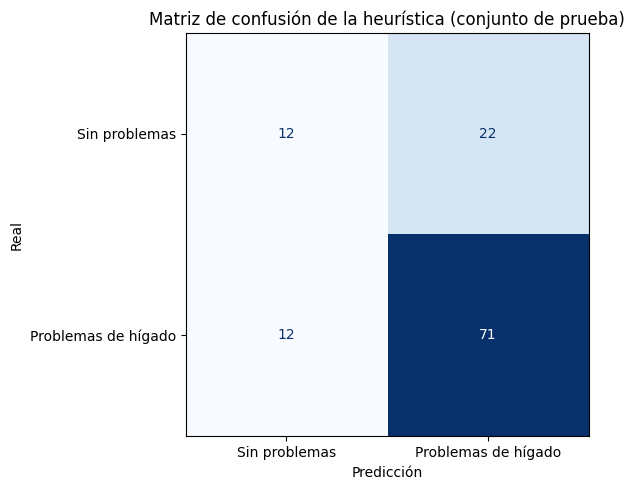

In [34]:
fig, ax = plt.subplots(figsize=(6.5, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["Sin problemas", "Problemas de hígado"],
    cmap="Blues",
    colorbar=False,
    ax=ax,
)
ax.set_title("Matriz de confusión de la heurística (conjunto de prueba)")
ax.set_xlabel("Predicción")
ax.set_ylabel("Real")
plt.tight_layout()
plt.show()

**Lectura de la matriz.** En el conjunto de prueba (117 pacientes):

- **71 verdaderos positivos**: enfermos correctamente señalados.
- **12 falsos negativos**: enfermos que la regla da por sanos (el 14,5% de los 83
  enfermos). En un contexto de tamizaje son el error más costoso: pacientes que no
  recibirían seguimiento.
- **12 verdaderos negativos**: sanos correctamente descartados.
- **22 falsos positivos**: sanos enviados innecesariamente a estudio posterior (el
  64,7% de los 34 sanos).

La asimetría del patrón es la firma de una regla OR con cortes sensibles: captura a
casi todos los enfermos (12 aciertos por cada error en la clase 1) a costa de
disparar alarmas sobre dos de cada tres sanos. Como referencia de tamizaje eso es
operativamente discutible pero informativo: establece cuánta detección se consigue
"gratis" con criterios de laboratorio y cuánta especificidad queda por ganar —que
es exactamente el margen que un modelo de Machine Learning debería aprovechar.

### Curvas ROC y precision-recall

El score de la heurística solo toma cinco valores (0 a 4 pruebas alteradas), así
que ambas curvas tienen pocos tramos. Aun así muestran algo valioso: cuánta
capacidad de ranking tiene "contar pruebas alteradas" sin ningún entrenamiento, y
qué le pasa a la precisión cuando se exige más recall.

AUC-ROC en prueba: 0.738
Average precision en prueba: 0.846


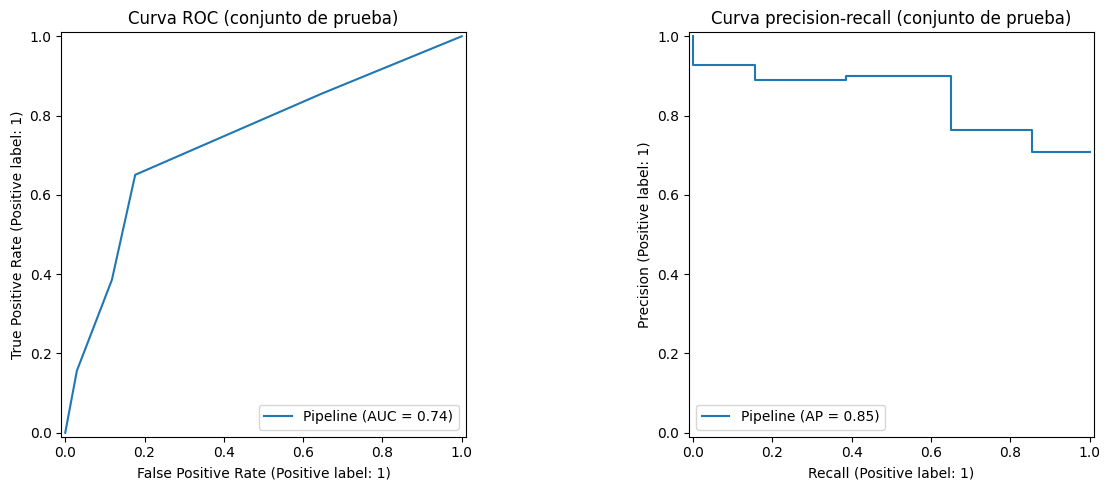

In [35]:
# score ordinal de la heurística (número de pruebas alteradas / 4)
y_score = modelo_base.predict_proba(x_test)[:, 1]
print(f"AUC-ROC en prueba: {roc_auc_score(y_test, y_score):.3f}")
print(f"Average precision en prueba: {average_precision_score(y_test, y_score):.3f}")

fig, (ax_roc, ax_pr) = plt.subplots(1, 2, figsize=(13, 5))

RocCurveDisplay.from_estimator(modelo_base, x_test, y_test, ax=ax_roc)
ax_roc.set_title("Curva ROC (conjunto de prueba)")

PrecisionRecallDisplay.from_estimator(modelo_base, x_test, y_test, ax=ax_pr)
ax_pr.set_title("Curva precision-recall (conjunto de prueba)")

plt.tight_layout()
plt.show()

**Lectura de las curvas.** El AUC-ROC de la heurística en prueba es **0,738**:
dado un paciente enfermo y uno sano al azar, el recuento de pruebas alteradas
ordena correctamente a los dos en el 74% de los casos, sin ningún entrenamiento.
Como referencia, el dummy de clase mayoritaria tiene AUC 0,500.

Ambas curvas tienen forma de escalera, porque el score solo toma cinco valores.
La curva precision-recall es la más informativa: la precisión arranca en ~0,93
(los 14 pacientes con las cuatro pruebas alteradas son casi todos enfermos) y se
mantiene alrededor de 0,9 hasta recall ~0,65 (umbral "2 o más pruebas"); pedir
solo "1 o más" —la regla actual— baja la precisión a 0,76 para llegar a recall
0,86, y marcar a todos la deja en la prevalencia (0,71). El average precision es
**0,846**. Es decir: los pacientes con varias pruebas alteradas son casi
seguramente enfermos, y toda la incertidumbre se concentra en la zona de 0–1
pruebas alteradas, donde viven los 12 falsos negativos y la mayoría de los 22
falsos positivos. Justamente esa zona gris es la que un modelo con pesos
aprendidos debería aprender a ordenar.

En resumen: "contar pruebas alteradas" ya contiene señal de ranking razonable
(AUC 0,738); un modelo que combine las variables debería empujar el AUC claramente
por encima de ese valor para justificar su complejidad.

## ✅ Validación cruzada del baseline

Repetimos la evaluación con validación cruzada estratificada de 10 folds, siempre
dentro del conjunto de entrenamiento: cada fold respeta la proporción 71/29 de
enfermos y la prueba sigue intacta.

- La **media** de cada métrica estima el desempeño esperable del baseline en datos
  nuevos.
- La **desviación estándar** mide cuánto varía el desempeño entre folds; valores
  altos indicarían que el resultado depende de qué pacientes caigan en cada fold,
  señal de inestabilidad. Con 468 pacientes de entrenamiento y folds de validación
  de ~47 pacientes, algo de variabilidad es inevitable.

In [36]:
metricas_cv = ["recall", "f1_macro", "roc_auc", "accuracy"]

resultados_cv = pd.DataFrame(
    {
        metrica: cross_val_score(
            modelo_base, x_train, y_train, cv=cv_estratificado, scoring=metrica
        )
        for metrica in metricas_cv
    }
)

tabla_cv = resultados_cv.T.round(3)
tabla_cv.columns = [f"Fold {indice + 1}" for indice in resultados_cv.index]
tabla_cv["media"] = resultados_cv.mean().round(3).to_numpy()
tabla_cv["desv. est."] = resultados_cv.std().round(3).to_numpy()
tabla_cv

,Fold 1,Fold 2,Fold 3,Fold 4,Fold 5,Fold 6,Fold 7,Fold 8,Fold 9,Fold 10,media,desv. est.
recall,0.824,0.788,0.970,0.818,0.939,0.818,1.000,0.909,0.848,0.848,0.876,0.073
f1_macro,0.525,0.610,0.682,0.417,0.619,0.591,0.605,0.601,0.436,0.582,0.567,0.083
roc_auc,0.681,0.681,0.826,0.655,0.760,0.707,0.742,0.734,0.617,0.737,0.714,0.059
accuracy,0.660,0.681,0.787,0.596,0.745,0.681,0.766,0.723,0.630,0.696,0.696,0.060


**Lectura de la validación cruzada.** Sobre los 10 folds del entrenamiento:

- **Recall de la clase 1: 0,876 ± 0,073.** La regla detecta en promedio al 88% de
  los enfermos; la desviación indica que ese porcentaje se mueve típicamente entre
  ~0,80 y ~0,95 (con un fold perfecto, 1,000). Con folds de validación de ~47
  pacientes, cada enfermo perdido mueve el recall ~2 puntos, así que parte de esa
  variabilidad es de muestreo y no del comportamiento de la regla.
- **f1_macro: 0,567 ± 0,083** y **AUC: 0,714 ± 0,059**: la discriminación es
  moderada y estable; ningún fold se desploma (el peor f1_macro es 0,417 y la peor
  AUC 0,617).
- **Accuracy: 0,696 ± 0,060**, otra vez pegada al piso tonto de 0,707.

El baseline es **razonablemente estable**: desviaciones de 6–8 puntos son las
esperables en un dataset de 468 registros, y no hay indicios de que el resultado
dependa críticamente de qué pacientes caigan en cada fold. El desempeño en prueba
(recall 0,855) quedó dentro del rango media ± desviación (0,803–0,949), lo que
confirma esa estabilidad.

## 📈 Curva de aprendizaje

La curva de aprendizaje muestra cómo cambia el desempeño según el tamaño del
conjunto de entrenamiento. Con 50 repeticiones de validación por tamaño
(`ShuffleSplit`), las bandas sombreadas indican la variabilidad del estimador.

Conviene ser honesto con lo que se puede esperar aquí: la heurística **no aprende**
de los datos —sus umbrales son fijos—, así que su desempeño no debería mejorar al
añadir más ejemplos. Lo que la curva sí puede mostrar es si el resultado de la
regla es estable y cuánta variabilidad de muestreo hay con conjuntos pequeños. Si
la curva resulta plana, eso no es un defecto: es la firma de un baseline sin
parámetros que aprender.

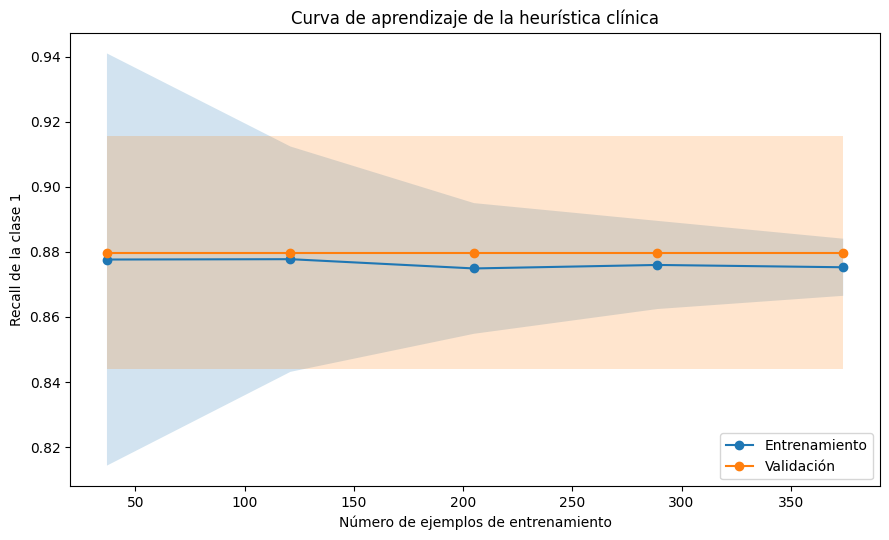

In [37]:
(
    tamanos_entrenamiento,
    scores_entrenamiento,
    scores_validacion,
    tiempos_fit,
    tiempos_score,
) = learning_curve(
    modelo_base,
    x_train,
    y_train,
    train_sizes=np.linspace(0.1, 1.0, 5),
    cv=ShuffleSplit(n_splits=50, test_size=0.2, random_state=123),
    scoring="recall",
    n_jobs=-1,
    return_times=True,
)

media_entrenamiento = scores_entrenamiento.mean(axis=1)
std_entrenamiento = scores_entrenamiento.std(axis=1)
media_validacion = scores_validacion.mean(axis=1)
std_validacion = scores_validacion.std(axis=1)

fig, ax = plt.subplots(figsize=(9, 5.5))

ax.plot(tamanos_entrenamiento, media_entrenamiento, "o-", label="Entrenamiento")
ax.fill_between(
    tamanos_entrenamiento,
    media_entrenamiento - std_entrenamiento,
    media_entrenamiento + std_entrenamiento,
    alpha=0.2,
)
ax.plot(tamanos_entrenamiento, media_validacion, "o-", label="Validación")
ax.fill_between(
    tamanos_entrenamiento,
    media_validacion - std_validacion,
    media_validacion + std_validacion,
    alpha=0.2,
)
ax.set_xlabel("Número de ejemplos de entrenamiento")
ax.set_ylabel("Recall de la clase 1")
ax.set_title("Curva de aprendizaje de la heurística clínica")
ax.legend(loc="lower right")

plt.tight_layout()
plt.show()

**Lectura de la curva de aprendizaje.** El resultado es el esperado para una regla
sin parámetros que aprender, y conviene leerlo como tal:

- La curva de **entrenamiento** es plana (~0,875 en todos los tamaños) y la de
  **validación** también (0,880 en los cinco tamaños, con desviación constante de
  0,036 entre las 50 repeticiones). Ambas están prácticamente superpuestas: no hay
  brecha porque no hay sobreajuste posible —la regla es la misma con 37 o con 374
  ejemplos.
- El desempeño **no mejora con más datos**, y eso no es un defecto del baseline:
  es su firma. Más ejemplos no pueden afinar umbrales que son fijos por diseño.

Lo que la curva sí aporta: una estimación honesta de la **variabilidad de
muestreo** del recall de la regla (±0,04 entre repeticiones con conjuntos de
validación del 20%), y la constatación de que incluso con solo ~40 ejemplos el
recall ya se sitúa en ~0,88. Para los modelos de Machine Learning de la siguiente
etapa, esta misma gráfica será diagnóstica de verdad: si su curva de validación
sube con más datos, estará aprendiendo estructura que la heurística no puede
capturar.

## ⏱️ Escalabilidad

Analizamos cómo escalan el tiempo de entrenamiento y el tiempo de predicción con el
tamaño del conjunto de entrenamiento. La expectativa para una regla de comparación
directa: el `fit` es prácticamente inmediato (solo aprende las medianas de
imputación) y la predicción crece de forma lineal con el número de pacientes.

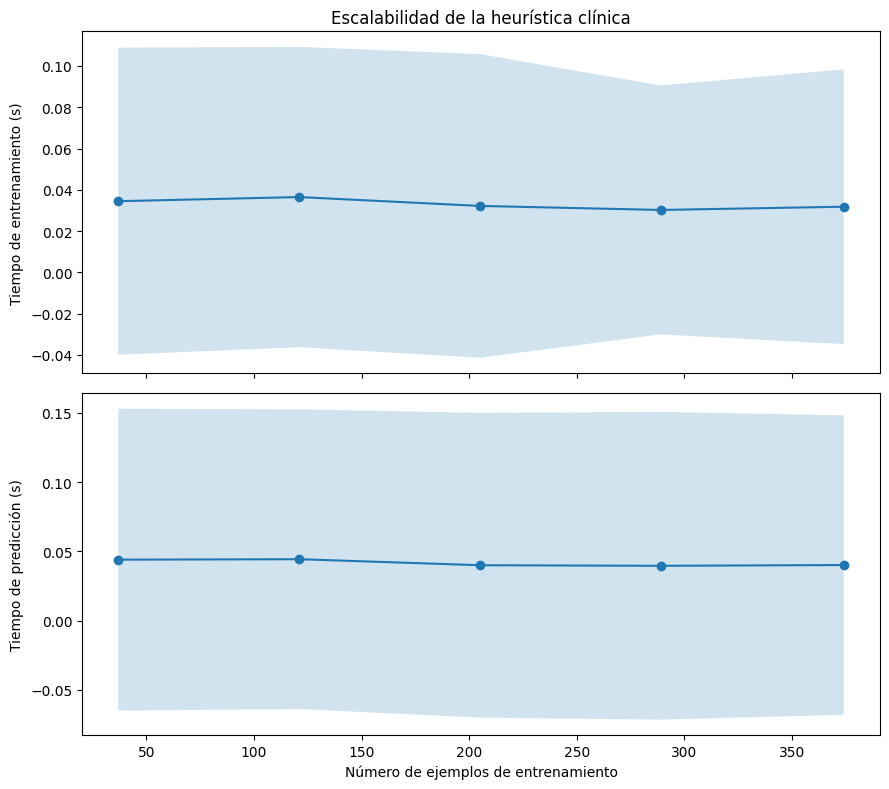

In [38]:
media_fit = tiempos_fit.mean(axis=1)
std_fit = tiempos_fit.std(axis=1)
media_score = tiempos_score.mean(axis=1)
std_score = tiempos_score.std(axis=1)

fig, (ax_fit, ax_score) = plt.subplots(2, 1, figsize=(9, 8), sharex=True)

ax_fit.plot(tamanos_entrenamiento, media_fit, "o-")
ax_fit.fill_between(
    tamanos_entrenamiento,
    media_fit - std_fit,
    media_fit + std_fit,
    alpha=0.2,
)
ax_fit.set_ylabel("Tiempo de entrenamiento (s)")
ax_fit.set_title("Escalabilidad de la heurística clínica")

ax_score.plot(tamanos_entrenamiento, media_score, "o-")
ax_score.fill_between(
    tamanos_entrenamiento,
    media_score - std_score,
    media_score + std_score,
    alpha=0.2,
)
ax_score.set_xlabel("Número de ejemplos de entrenamiento")
ax_score.set_ylabel("Tiempo de predicción (s)")

plt.tight_layout()
plt.show()

**Lectura de la escalabilidad.** Los números confirman lo que se esperaba de una
regla de comparación directa:

- El **tiempo de entrenamiento** es de ~0,03 s y no crece con el tamaño del
  conjunto: el `fit` solo aprende cuatro medianas de imputación, trabajo constante
  sea cual sea el número de pacientes.
- El **tiempo de predicción** ronda los 0,03 s por fold de validación (~94
  pacientes) y tampoco crece de forma apreciable.
- Las desviaciones estándar (del mismo orden que las medias) son ruido de medición
  en la escala de milisegundos, no una señal real de variabilidad de coste.

En términos prácticos, el costo del baseline es despreciable a cualquier escala
realista de este problema: procesar los 585 pacientes del dataset completo toma
milisegundos. La lectura útil para la siguiente etapa es de contraste: cualquier
modelo de Machine Learning que se entrene sobre estos datos tendrá aquí su techo
de costo de referencia, y con 585 registros ninguno debería ser prohibitivo.

## 📊 Interpretación de resultados

### Síntesis: ¿qué tan bien funciona el baseline?

**Como detector, razonable; como clasificador, débil en la clase sana.** La
heurística detecta al 86% de los enfermos de prueba (71 de 83) y ordena pacientes
mejor que el azar (AUC 0,738), pero descarta correctamente a solo 1 de cada 3
sanos (12 de 34) y etiqueta como "sin problemas" a 12 enfermos. La accuracy de
0,71 es indistinguible del piso tonto (0,708): con este desbalance, la accuracy no
aporta información y las decisiones deben leerse en las métricas por clase.

**Los errores tienen estructura.** Los 12 falsos negativos son enfermos con 0
pruebas alteradas según los cortes de laboratorio —pacientes de daño leve o
temprano que una regla de umbrales no puede ver—, y los 22 falsos positivos son
sanos con alguna prueba rozando el límite. Toda la incertidumbre se concentra en
la zona de 0–1 pruebas alteradas; con 2 o más, la precisión supera el 0,89.

**Es estable.** La validación cruzada (recall 0,876 ± 0,073, AUC 0,714 ± 0,059)
no muestra folds desplomados y el resultado de prueba cae dentro del rango
esperado. La curva de aprendizaje plana con curvas superpuestas confirma que el
comportamiento no depende del tamaño del conjunto: la regla no aprende, y su
desempeño es una propiedad del corte clínico, no de los datos de ajuste.

**El costo computacional es nulo** (~0,03 s de entrenamiento y de predicción).

### Limitaciones

- Score ordinal de 5 niveles, sin calibración probabilística.
- Cada prueba se evalúa de forma aislada: la regla no puede combinar información
  (por ejemplo, bilirrubina 1,1 con albúmina 2,9 es "normal" para ella).
- Umbrales de referencia generales, no específicos para esta población.
- La regla hereda el desbalance del problema: con 71% de prevalencia, incluso
  marcar al azar acierta mucho.

**Qué debería demostrar un futuro modelo de Machine Learning:** superar de forma
significativa y estable el f1_macro ~0,57 y el AUC ~0,71 de la validación cruzada
(el AUC 0,738 y el f1_macro 0,61 de prueba), manteniendo un recall ≥ 0,88. El
progreso debería venir sobre todo de dos frentes: reducir los 12 falsos negativos
(detectar a los enfermos "de daño leve") y aumentar la especificidad sin sacrificar
sensibilidad.

## 📈 Conclusiones

Con los resultados sobre la mesa, esta etapa deja cuatro aprendizajes:

1. **El piso tonto está en 0,707 de accuracy.** Cualquier modelo que se reporte
   solo con accuracy en este problema estará inflando su resultado: hay que exigir
   métricas por clase (y AUC) desde ahora.
2. **Una regla clínica sin entrenamiento ya detecta al 88% de los enfermos**
   (validación cruzada) con AUC 0,714. Esa es la referencia real que los modelos
   de Machine Learning deben superar de forma clara: no basta con ganarle al
   dummy, hay que ganarle a cuatro umbrales de laboratorio.
3. **El margen de mejora está identificado:** los enfermos con pruebas en rango
   (12 falsos negativos en prueba) y la especificidad (64,7% de falsos alarmas
   entre los sanos). La zona gris de 0–1 pruebas alteradas concentra toda la
   incertidumbre.
4. **El baseline es gratuito, reproducible e interpretable.** Tiempos de ~0,03 s,
   ningún parámetro aprendido, y cada predicción se puede explicar en una frase
   ("tiene la albúmina baja"). Cualquier modelo más complejo deberá compensar la
   pérdida de esa simplicidad con una mejora de desempeño real.

El baseline cumple su propósito: queda establecido, documentado y listo como
referencia de comparación para la etapa de modelado.

## 🧑‍🔬 Recomendaciones

Para la etapa de modelado, con base en lo observado:

1. **Priorizar recall de la clase 1 y f1_macro como métricas de selección**, y
   reportar siempre la matriz de confusión. La accuracy debe reportarse solo como
   contexto, nunca como criterio de decisión: el piso tonto la iguala.
2. **Atacar los falsos negativos de daño leve.** Los 12 enfermos con cero pruebas
   alteradas solo son detectables combinando variables (por ejemplo, varias
   pruebas "normales-altas" a la vez). Es exactamente el tipo de patrón que un
   modelo con pesos aprendidos puede capturar y una regla de umbrales no.
3. **Vigilar la especificidad.** Un modelo que mantenga recall ~0,88 bajando los
   falsos positivos de 22 a la mitad ya sería un avance operativo tangible.
4. **Tratar el desbalance explícitamente:** evaluar ponderación de clases y
   reportar resultados también con umbrales distintos al 0,5 por defecto; con la
   curva precision-recall de esta etapa como referencia de lo que cada punto de
   recall cuesta en precisión.
5. **Mantener la disciplina anti-fuga de esta etapa:** ajustar todo dentro del
   pipeline, solo con el entrenamiento, y tocar la prueba una única vez por
   modelo. Con 585 registros, cualquier fuga pequeña inflaría mucho las métricas.
6. **Variables para analizar después:** `Age` (señal débil pero significativa, no
   usada por la heurística), el cociente de De Ritis ya construido en el Feature
   Engineering, y resultados separados por género, dado que las mujeres son el 24%
   de la muestra.

## 💡 Propuestas para futuros modelos

Propuestas concretas para la siguiente etapa (aquí solo quedan anotadas; no se
implementan):

- **Comparar varios algoritmos sencillos sobre el pipeline de 13 columnas del
  Feature Engineering**: regresión logística (interpretable, buen punto de
  partida), k-vecinos y árbol de decisión; si la ganancia lo justifica, ensembles.
  Todos contra el mismo split estratificado y la misma validación cruzada de este
  notebook, para que la comparación con el baseline sea directa.
- **Análisis de importancia de variables** con modelos que sí aprenden de las
  predictoras (coeficientes de la regresión logística, importancia por
  permutación): es la continuación natural de la sección de variables de esta
  etapa, donde los dummies no tienen nada que aportar.
- **Estudio del desbalance**: ponderación de clases, umbrales de decisión
  optimizados sobre la curva precision-recall y, si se considera, sobremuestreo
  dentro del pipeline (imblearn), siempre ajustado solo con el entrenamiento.
- **Análisis de errores**: caracterizar a los 12 falsos negativos de prueba
  (edad, género, valores cercanos al umbral) para entender si son un subgrupo
  clínico real.
- **Interpretabilidad**: si el modelo final no es intrínsecamente interpretable,
  acompañarlo de explicaciones por predicción (SHAP), conservando la trazabilidad
  que la heurística ofrece de forma natural.
- **Comparación explícita contra este baseline** en el informe final: tabla con
  recall, especificidad, f1_macro y AUC de la heurística y de cada modelo, para
  que la decisión de producción se tome con la mejora relativa a la vista.

## 📖 Referencias

- Documentación de scikit-learn sobre validación cruzada:
  <https://scikit-learn.org/stable/modules/cross_validation.html>
- Documentación de scikit-learn sobre curvas de aprendizaje:
  <https://scikit-learn.org/stable/modules/learning_curve.html>
- Documentación de scikit-learn sobre métricas de clasificación:
  <https://scikit-learn.org/stable/modules/model_evaluation.html>
- Documentación de `DummyClassifier`:
  <https://scikit-learn.org/stable/modules/generated/sklearn.dummy.DummyClassifier.html>
- Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow (2ª edición),
  Aurélien Géron — capítulo 2, sobre el papel del baseline en un proyecto de
  Machine Learning.
- Dataset ILPD (Indian Liver Patient Dataset):
  <https://archive.ics.uci.edu/dataset/225/ilpd+indian+liver+patient+dataset>